# Experimental Churn Modeling

This notebook attempts to perform data preprocessing and identify approach (preprocessing, feature engineering, model family) that works for best for this problem.

## initial setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# feature engineering
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder

# models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# experiment and tracking
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, recall_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df_raw  = df.copy()

df['Flag_Missing'] = df.isna().any(axis=1).astype(int)

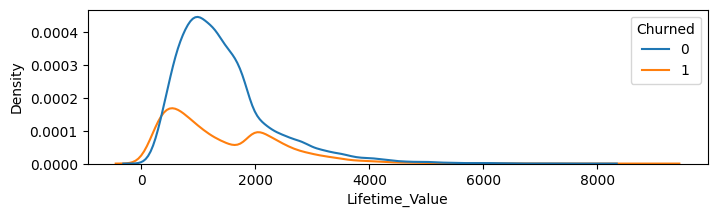

In [3]:
plt.figure(figsize=(8, 2))
sns.kdeplot(df, x='Lifetime_Value', hue='Churned')
plt.show()

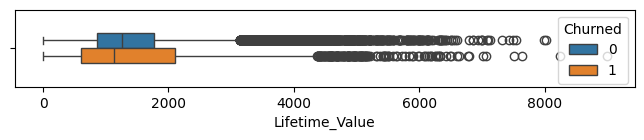

In [4]:
plt.figure(figsize=(8, 1))
sns.boxplot(df, x='Lifetime_Value', hue='Churned', width=0.4)
plt.show()

## check for multicollinearity

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# floats are all the numeric cols
num_cols = df.dropna().select_dtypes(float).columns
vif_data = [variance_inflation_factor(df.dropna().select_dtypes(float).values, i) for i in range(num_cols.size)]
vif = pd.DataFrame({
    'feature': num_cols,
    'VIF': vif_data
})

In [6]:
vif.sort_values('VIF')

,feature,VIF
8,Average_Order_Value,1.580026
9,Days_Since_Last_Purchase,1.997038
11,Returns_Rate,2.611092
1,Membership_Years,3.053466
14,Product_Reviews_Written,4.670723
10,Discount_Usage_Rate,4.715345
17,Payment_Method_Diversity,5.277947
19,Credit_Balance,6.133862
13,Customer_Service_Calls,6.135915
6,Wishlist_Items,6.438491


The last 2 (`Session_Duration_Avg` and `Pages_Per_Session`) appears on higher end of multicolinearity, which would correlate in an ecom. 
* More pages per session → longer session duration

* Longer session duration → more pages viewed

For now all columns are used for baseline, later will experiment with dropping and/or combining them.

## drop and flag
govern by conclusion from data validation

In [7]:
# filter out only invalid record
mask = (((df['Age'] <= 100) | df['Age'].isna()) &
        ((df['Lifetime_Value'] >= 0) | df['Lifetime_Value'].isna())
        )

df = df[mask]

# Direct filtering would drop NaNs (since comparisons return False), so we explicitly retain them.

> direct filtering using valid condition operation will also include False for missing/nan values - which are treated seperately.

In [8]:
# flags only invalid records
df['Flag_Purchases_Invalid'] = ((df['Total_Purchases'] < 0) & 
                                df['Total_Purchases'].notna()
                                ).astype(np.uint8)

df['Flag_Discount_Rate_Invalid'] = ((df['Discount_Usage_Rate'] > 100) 
                                    & df['Discount_Usage_Rate'].notna()
                                    ).astype(np.uint8)

df['Flag_Membership_Age_Invalid'] = ((df['Membership_Years'] > df['Age']) & 
                                     df['Membership_Years'].notna() &
                                     df['Age'].notna()
                                     ).astype(np.uint8)

In [9]:
# flag extreme - Average Order Value
df['Flag_AOV_Extreme'] = ((df['Average_Order_Value'] > 400) &
                          df['Average_Order_Value'].notna()
                          ).astype(np.uint8)

In [10]:
print(f"Rows after drops: {len(df):,}", end="\n\n")
print("Following flags are created:")
print(f"{df[['Flag_Purchases_Invalid','Flag_Discount_Rate_Invalid','Flag_Membership_Age_Invalid','Flag_AOV_Extreme']].sum()}")

Rows after drops: 49,980

Following flags are created:
Flag_Purchases_Invalid          40
Flag_Discount_Rate_Invalid     207
Flag_Membership_Age_Invalid      5
Flag_AOV_Extreme                25
dtype: uint64


## train test split

In [11]:
# Missingness Proportion
df['Flag_Missing'] = df.isna().any(axis=1).astype(np.uint8)

print(f"Rows with missing values: {df['Flag_Missing'].sum():,}")

Rows with missing values: 32,007


In [12]:
X = df.drop('Churned', axis=1)
y = df['Churned']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, train_size=0.7, stratify=y, random_state=42
)

In [13]:
for flag_col in ['Flag_AOV_Extreme', 'Flag_Purchases_Invalid', 'Flag_Membership_Age_Invalid', 'Flag_Missing']:
    print(f"{flag_col} → train: {Xtrain[flag_col].sum()}, test: {Xtest[flag_col].sum()}")

Flag_AOV_Extreme → train: 18, test: 7
Flag_Purchases_Invalid → train: 32, test: 8
Flag_Membership_Age_Invalid → train: 4, test: 1
Flag_Missing → train: 22390, test: 9617


The train test split has distributed the concern cases of invalid, extreme, and missing properly. No need to stratify on them.

## impute numeric missing 

The features which are count based and have presence of 0 (e.g., no whishlist), missingness doesn't back the 0 count (e.g., nan means 0 wishlist item) assumption.

In [14]:
Xtrain.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Signup_Quarter', 'Flag_Missing', 'Flag_Purchases_Invalid',
       'Flag_Discount_Rate_Invalid', 'Flag_Membership_Age_Invalid',
       'Flag_AOV_Extreme'],
      dtype='object')

In [15]:
missing_counts_sparse = Xtrain.isna().sum()
missing_cols = missing_counts_sparse[missing_counts_sparse > 0 ].index


missing_counts = missing_counts_sparse[missing_cols]
missing_skews = Xtrain[missing_cols].skew()
missing_kurts = Xtrain[missing_cols].kurt()

stats_prop = pd.DataFrame({
    'counts': missing_counts,
    'skew': missing_skews,
    'kurt': missing_kurts
})

stats_prop

,counts,skew,kurt
Age,1723,0.222038,-0.373352
Session_Duration_Avg,2380,0.398770,-0.086706
Pages_Per_Session,2079,0.392513,-0.115255
Wishlist_Items,2740,0.957157,0.991609
Days_Since_Last_Purchase,2122,1.991616,5.637814
Discount_Usage_Rate,2433,0.370241,-0.437568
Returns_Rate,3177,6.006804,74.115428
Email_Open_Rate,1823,0.488844,-0.233111
Customer_Service_Calls,120,0.447583,0.162367
Product_Reviews_Written,2412,1.022253,1.157340


Some of the features are skewed and/or heavy tails, so median is used for imputation for reduced effect of outliers.

In [16]:
# simple median impute
median_imputer = SimpleImputer(strategy='median').set_output(transform='pandas')
median_imputer.fit(Xtrain[num_cols])

SimpleImputer(strategy='median')

In [17]:
Xtrain_missing_fix = median_imputer.transform(Xtrain[num_cols])
Xtrain = Xtrain.combine_first(Xtrain_missing_fix)

Xtest_missing_flag = Xtest.isna().any(axis=1)
Xtest_missing_fix = median_imputer.transform(Xtest[num_cols])
Xtest = Xtest.combine_first(Xtest_missing_fix)

In [18]:
Xtrain.isna().sum().sum()

np.int64(0)

## encoding categorical columns

In [19]:
Xtrain.select_dtypes('O').head()

,City,Country,Gender,Signup_Quarter
19328,Manchester,UK,Female,Q4
27752,Leeds,UK,Male,Q4
11030,Chicago,USA,Male,Q4
34662,Phoenix,USA,Male,Q1
5036,Phoenix,USA,Female,Q2


In [20]:
Xtrain.select_dtypes('O').nunique()

City              40
Country            8
Gender             3
Signup_Quarter     4
dtype: int64

In [21]:
for col in Xtrain.select_dtypes('O').columns:
    print(f"{col}: {Xtrain[col].unique()}")

City: ['Manchester' 'Leeds' 'Chicago' 'Phoenix' 'Toronto' 'Houston'
 'Los Angeles' 'Frankfurt' 'Sydney' 'New York' 'Glasgow' 'Adelaide'
 'Kyoto' 'Perth' 'Toulouse' 'Mumbai' 'Berlin' 'Delhi' 'Hamburg' 'Paris'
 'Hyderabad' 'London' 'Cologne' 'Lyon' 'Birmingham' 'Montreal' 'Marseille'
 'Calgary' 'Ottawa' 'Chennai' 'Nice' 'Yokohama' 'Osaka' 'Vancouver'
 'Munich' 'Nagoya' 'Melbourne' 'Brisbane' 'Bangalore' 'Tokyo']
Country: ['UK' 'USA' 'Canada' 'Germany' 'Australia' 'Japan' 'France' 'India']
Gender: ['Female' 'Male' 'Other']
Signup_Quarter: ['Q4' 'Q1' 'Q2' 'Q3']


In [22]:
low_cardinal_cols = ['Gender', 'Signup_Quarter', 'Country']
mid_cardinal_cols = ['City']

#### low cardinality variables

In [23]:
# one hot encoding
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=np.uint8, handle_unknown='error').set_output(transform='pandas')
ohe.fit(Xtrain[low_cardinal_cols])

Xtrain_lowcard_ = ohe.transform(Xtrain[low_cardinal_cols])
Xtrain = pd.concat([Xtrain, Xtrain_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)

Xtest_lowcard_ = ohe.transform(Xtest[low_cardinal_cols])
Xtest = pd.concat([Xtest, Xtest_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)

#### moderate/mid cardinality variable

In [24]:
[X[col].value_counts().values for col in mid_cardinal_cols]

[array([3547, 3489, 3476, 3474, 3390, 1576, 1535, 1528, 1458, 1435, 1247,
        1209, 1204, 1182, 1181, 1033, 1026, 1013,  960,  893,  828,  828,
         817,  815,  815,  805,  799,  793,  793,  776,  733,  698,  694,
         693,  691,  536,  513,  507,  496,  494])]

City acts like a subcategory with Country as main category. Performing one-hot encoding on city aswell can cause a dimensionality curse and multicolinearity issue.

From eda, these categorical variables show little-to-no linear correlation with target variable (`Churned`). 

In [25]:
# Frequency encoding for City
freq_map = Xtrain['City'].value_counts(normalize=True)
Xtrain['City'] = Xtrain['City'].replace(freq_map)
Xtest['City'] = Xtest['City'].replace(freq_map)

In [26]:
Xtrain.dtypes.value_counts()

float64    21
uint8      17
Name: count, dtype: int64

## model specific train data

In [27]:
Xtrain_base = Xtrain.copy()
Xtest_base = Xtest.copy()

pd.concat([Xtrain_base, ytrain], axis=1).to_parquet("../data/interim/base/train.parquet")
pd.concat([Xtest_base, ytest], axis=1).to_parquet("../data/interim/base/test.parquet")

In [28]:
# tree path
Xtrain_tree = Xtrain_base.copy()
Xtest_tree = Xtest_base.copy()

In [29]:
# for non tree based models 
Xtrain_nontree = Xtrain_base.copy()
Xtest_nontree = Xtest_base.copy()

num_cols = Xtrain_nontree.select_dtypes(include='number').columns.difference(
    [c for c in Xtrain_nontree.columns if c.startswith('Flag_')]
)

# -------------- log transform skewed columns +1 to handle zeros ------------- #
# skewed_cols = ['Total_Purchases', 'Days_Since_Last_Purchase', 
#                'Returns_Rate', 'Average_Order_Value', 'Lifetime_Value', 'Membership_Years']
skewed_cols = num_cols

Xtrain_nontree[skewed_cols] = np.log1p(Xtrain_nontree[skewed_cols].clip(lower=0))
Xtest_nontree[skewed_cols] = np.log1p(Xtest_nontree[skewed_cols].clip(lower=0))


# ----------------- iqr based scaling to handle extreme outlier --------------- #
scaler = RobustScaler()
num_cols = Xtrain_nontree.select_dtypes(include='number').columns.difference(
    [c for c in Xtrain_nontree.columns if c.startswith('Flag_')]
)
Xtrain_nontree[num_cols] = scaler.fit_transform(Xtrain_nontree[num_cols])
Xtest_nontree[num_cols] = scaler.transform(Xtest_nontree[num_cols])


# ------------------------------- save dataset ------------------------------- #
pd.concat([Xtrain_nontree, ytrain], axis=1)\
    .to_parquet("../data/interim/transformed/train.parquet")
pd.concat([Xtest_nontree, ytest], axis=1)\
    .to_parquet("../data/interim/transformed/test.parquet")

Outdated (ignore)

> note: log transform isn't performed as skewed columns (AOV, Returns_Rate, Total_Purchases, Days_Since_Last_Purchase) exhibit disjoint outlier clusters rather than continuous right-skewed tails 
> 
> log transform doesn't fix disjoint structure; it can compresses continuous tails by reducing the scale of large values, which doesn't apply here.
> 
> RobustScaler (median/IQR based) handles these sufficiently; that's why it is performed on all numeric data.
> 

## model experiments

**skipped:**

* SVM  - very slow to train on 35k records (training data)
* Naive Bayes - assumes all features are independent, while the multicollinearity test showed high vif and confirm some multicollinearity between features. 

### base and scaled features

In [30]:
base_features = Xtrain_base.columns.values

In [31]:
import os
import mlflow
from mlflow.tracking import MlflowClient

project_root = os.path.abspath("..")
artifact_root = f"file:///{project_root}/mlflow/artifacts"
tracking_db = f"sqlite:///{project_root}/mlflow/tracking.db"

mlflow.set_tracking_uri(tracking_db)

client = MlflowClient()
exp_name = "churn-model-family-selection"

exp = client.get_experiment_by_name(exp_name)

if exp:
    if exp.lifecycle_stage == "deleted":
        client.restore_experiment(exp.experiment_id)

    # 🔥 delete all runs instead of experiment
    runs = client.search_runs([exp.experiment_id])
    for run in runs:
        client.delete_run(run.info.run_id)

else:
    mlflow.create_experiment(exp_name, artifact_location=artifact_root)

mlflow.set_experiment(exp_name)

<Experiment: artifact_location='file:///e:\\Projects\\ecom-customer-behaviour/mlflow/artifacts', creation_time=1777821144801, experiment_id='1', last_update_time=1777888042600, lifecycle_stage='active', name='churn-model-family-selection', tags={}, workspace='default'>

In [32]:
models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000),       Xtrain_nontree, Xtest_nontree,      "robust-scaler"),
    ("KNN",                KNeighborsClassifier(),                  Xtrain_nontree, Xtest_nontree,      "robust-scaler"),
    ("DecisionTree",       DecisionTreeClassifier(),                Xtrain_tree,    Xtest_tree,         "base"),
    ("RandomForest",       RandomForestClassifier(),                Xtrain_tree,    Xtest_tree,         "base"),
    ("XGBoost",            XGBClassifier(eval_metric='logloss'),    Xtrain_tree,    Xtest_tree,         "base"),
]

results = []

for name, model, Xtrain_, Xtest_, path in models:
    with mlflow.start_run(run_name=name):
        # train
        features = Xtrain_.columns.to_list()
        model.fit(Xtrain_, ytrain)

        # predict
        y_prob = model.predict_proba(Xtest_)[:, 1]
        y_pred = model.predict(Xtest_)

        # metrics
        auc    = roc_auc_score(ytest, y_prob)
        ap     = average_precision_score(ytest, y_prob)
        acc    = accuracy_score(ytest, y_pred)
        rc     = recall_score(ytest, y_pred)

        # mlflow logs
        mlflow.log_param("preprocessing_path", path)
        mlflow.log_param("feature_counts", len(features))
        mlflow.log_metric("recall", rc)
        mlflow.log_metric("avg_precision", ap)
        mlflow.log_metric("auc_roc", auc)
        mlflow.log_metric("accuracy", acc)
        
        # mlflow.sklearn.log_model(model, name)
        ## note: models not saved as experiement aims to identify model family and features.
        
        # # mlflow log artifact
        # with open("../features.txt", "w") as f:
        #     f.write("\n".join(features))
        # mlflow.log_artifact("../features.txt")
        
        results.append({"model": name, 
                        "path": path, 
                        "recall": rc,
                        "auc_roc": auc, 
                        "avg_precision": ap, 
                        "accuracy": acc})
        # print(f"{name} → AUC: {auc:.4f} | Avg Precision: {ap:.4f} | Accuracy: {acc:.4f}")
        print(f'\rtraining {name}'.ljust(100), end='', flush=True)
        
print(f'\rtraining done'.ljust(100), end='', flush=True)

training done                                                                                      

These models are not logged as they're intermediate and irrelevant to final production pipeline.

In [33]:
# comparison table - base and scaled features 
results_df = pd.DataFrame(results).sort_values("recall", ascending=False)
results_df

,model,path,recall,auc_roc,avg_precision,accuracy
4,XGBoost,base,0.786571,0.924912,0.904041,0.915099
3,RandomForest,base,0.767190,0.923496,0.900109,0.913632
2,DecisionTree,base,0.742501,0.811025,0.605165,0.839936
1,KNN,robust-scaler,0.443009,0.790415,0.599748,0.790049
0,LogisticRegression,robust-scaler,0.405399,0.783644,0.626887,0.773509


In [34]:
# trained model
model_registry = dict({1: models.copy()})

On the baseline feature set, decision tree appears reasonable as its balances explainability and prediction performance.

Among the non-tree baselines, Logistic Regression remains the most interpretable option and edges KNN on the engineered dataset in recall, ROC-AUC, average precision, and accuracy.

### feature creation

In [35]:
# address multicolinearity (high vif) - combine both

def build_features(Xtrain_, Xtest_):
    for df_ in [Xtrain_, Xtest_]:
        df_['Engagement_Score'] = df_['Pages_Per_Session'] * df_['Session_Duration_Avg']
        df_['Purchase_Frequency'] = df_['Total_Purchases'] / (df_['Days_Since_Last_Purchase'].clip(lower=0) + 1)
        df_['LTV_Per_Purchase'] = df_['Lifetime_Value'] / (df_['Total_Purchases'].clip(lower=0) + 1)
    return Xtrain_, Xtest_

Xtrain_tree, Xtest_tree = build_features(Xtrain_tree, Xtest_tree)
Xtrain_nontree, Xtest_nontree = build_features(Xtrain_nontree, Xtest_nontree)

The division component has lower clipped to zero prevents -ve invalid values from making denominator 0 even after the +1.

In [36]:
new_fe = ['Engagement_Score', 'Purchase_Frequency', 'LTV_Per_Purchase']
models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000),   Xtrain_nontree, Xtest_nontree,  "robust-scaler", new_fe),
    ("L1-LogisticRegression",LogisticRegression(penalty='l1', 
                                              solver='liblinear', 
                                              max_iter=1000),   Xtrain_nontree, Xtest_nontree,  "robust-scaler", new_fe),
    ("L2-LogisticRegression", LogisticRegression(penalty='l2', 
                                              max_iter=1000),   Xtrain_nontree, Xtest_nontree,  "robust-scaler", new_fe),
    ("KNN",                KNeighborsClassifier(),              Xtrain_nontree, Xtest_nontree,  "robust-scaler", new_fe),
    ("DecisionTree",       DecisionTreeClassifier(),            Xtrain_tree,    Xtest_tree,     "base", new_fe),
    ("RandomForest",       RandomForestClassifier(),            Xtrain_tree,    Xtest_tree,     "base", new_fe),
    ("XGBoost",            XGBClassifier(eval_metric='logloss'), Xtrain_tree,   Xtest_tree,     "base", new_fe),
]

results = []

for name, model, Xtrain_, Xtest_, path, new_fe in models:
    with mlflow.start_run(run_name=name):
        # train
        features = Xtrain_.columns.to_list()
        model.fit(Xtrain_, ytrain)

        # predict
        y_prob = model.predict_proba(Xtest_)[:, 1]
        y_pred = model.predict(Xtest_)

        # metrics
        auc    = roc_auc_score(ytest, y_prob)
        ap     = average_precision_score(ytest, y_prob)
        acc    = accuracy_score(ytest, y_pred)
        rc     = recall_score(ytest, y_pred)

        # mlflow logs
        mlflow.log_param("preprocessing_path", path)
        mlflow.log_param("feature_counts", len(features))
        mlflow.log_metric("recall", rc)
        mlflow.log_metric("avg_precision", ap)
        mlflow.log_metric("auc_roc", auc)
        mlflow.log_metric("accuracy", acc)
        
        # mlflow tags
        for feature in new_fe:
            mlflow.set_tag(feature, 'create')
        
        results.append({"model": name, 
                        "path": path, 
                        "recall": rc,
                        "auc_roc": auc, 
                        "avg_precision": ap, 
                        "accuracy": acc,
                        "new_fe": new_fe})

        print(f'\rtraining {name}'.ljust(100), end='', flush=True)
        
print(f'\rtraining done'.ljust(100), end='', flush=True)
mlflow.end_run()

training done                                                                                      

In [37]:
# comparision of model with engineered features dataset 
results_df = pd.concat([results_df, pd.DataFrame(results)])
results_df.sort_values("recall", ascending=False)

,model,path,recall,auc_roc,avg_precision,accuracy,new_fe
6,XGBoost,base,0.787263,0.923789,0.903536,0.915833,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
4,XGBoost,base,0.786571,0.924912,0.904041,0.915099,NaN
5,RandomForest,base,0.775958,0.923194,0.897453,0.913899,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
3,RandomForest,base,0.767190,0.923496,0.900109,0.913632,NaN
4,DecisionTree,base,0.753576,0.820222,0.621582,0.848339,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
2,DecisionTree,base,0.742501,0.811025,0.605165,0.839936,NaN
1,L1-LogisticRegression,robust-scaler,0.466082,0.814966,0.679114,0.794718,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
0,LogisticRegression,robust-scaler,0.464006,0.814904,0.679109,0.794184,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
2,L2-LogisticRegression,robust-scaler,0.464006,0.814904,0.679109,0.794184,"[Engagement_Score, Purchase_Frequency, LTV_Per..."
3,KNN,robust-scaler,0.452007,0.792904,0.606056,0.792850,"[Engagement_Score, Purchase_Frequency, LTV_Per..."


In [38]:
pd.concat([Xtrain_tree, ytrain], axis=1)\
    .to_parquet("../data/interim/new-features/train.parquet")
pd.concat([Xtest_tree, ytest], axis=1)\
    .to_parquet("../data/interim/new-features/test.parquet")

In [39]:
model_registry[2]= models.copy()

Feature creation gives small but consistent gains: 

XGBoost recall improves to 0.7873, Random Forest to 0.7760, Decision Tree to 0.7536, and Logistic Regression to 0.4640. The ranking does not change, but the engineered features help every family except only a negligible shift for some metrics.

### drop multi-collinear feature

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# floats are all the numeric cols
df_num = df_raw.select_dtypes(include='number')\
    .dropna()\
    .drop(columns=['Session_Duration_Avg', 
                   'Pages_Per_Session', 
                   'Total_Purchases', 
                   'Cart_Abandonment_Rate']
          )

vif = pd.DataFrame({
    "feature": df_num.columns,
    "VIF": [
        variance_inflation_factor(df_num.values, i)
        for i in range(df_num.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)[:5]

,feature,VIF
12,Mobile_App_Usage,14.704243
0,Age,8.350998
2,Login_Frequency,8.144868
8,Email_Open_Rate,6.777904
11,Social_Media_Engagement_Score,6.323532


In [41]:
new_fe = ['Engagement_Score', 'Purchase_Frequency', 'LTV_Per_Purchase']
drop_fe = ['Session_Duration_Avg', 'Pages_Per_Session', 'Total_Purchases', 'Cart_Abandonment_Rate']

Xtrain_nontree_fe = Xtrain_nontree.drop(columns=drop_fe)
Xtest_nontree_fe = Xtest_nontree.drop(columns=drop_fe)

Xtrain_tree_fe = Xtrain_tree.drop(columns=drop_fe)
Xtest_tree_fe = Xtest_tree.drop(columns=drop_fe)


models = [
    ("LogisticRegression", LogisticRegression(max_iter=1000),   Xtrain_nontree_fe, Xtest_nontree_fe,  "robust-scaler", new_fe, drop_fe),
    ("LogisticL1Regression",    LogisticRegression(penalty='l1', 
                                              solver='liblinear', 
                                              max_iter=1000),   Xtrain_nontree_fe, Xtest_nontree_fe,  "robust-scaler", new_fe, drop_fe),
    ("LogisticL2Regression",    LogisticRegression(penalty='l2', 
                                              max_iter=1000),   Xtrain_nontree_fe, Xtest_nontree_fe,  "robust-scaler", new_fe, drop_fe),
    ("KNN",                KNeighborsClassifier(),              Xtrain_nontree_fe, Xtest_nontree_fe,  "robust-scaler", new_fe, drop_fe),
    ("DecisionTree",       DecisionTreeClassifier(),            Xtrain_tree_fe,    Xtest_tree_fe,     "base", new_fe, drop_fe),
    ("RandomForest",       RandomForestClassifier(),            Xtrain_tree_fe,    Xtest_tree_fe,     "base", new_fe, drop_fe),
    ("XGBoost",            XGBClassifier(eval_metric='logloss'), Xtrain_tree_fe,   Xtest_tree_fe,     "base", new_fe, drop_fe),
]

results = []

for name, model, Xtrain_, Xtest_, path, new_fe, drop_fe in models:
    with mlflow.start_run(run_name=name):
        # train
        features = Xtrain_.columns.to_list()
        model.fit(Xtrain_, ytrain)

        # predict
        y_prob = model.predict_proba(Xtest_)[:, 1]
        y_pred = model.predict(Xtest_)

        # metrics
        auc    = roc_auc_score(ytest, y_prob)
        ap     = average_precision_score(ytest, y_prob)
        acc    = accuracy_score(ytest, y_pred)
        rc     = recall_score(ytest, y_pred)

        # mlflow logs
        mlflow.log_param("preprocessing_path", path)
        mlflow.log_param("feature_counts", len(features))
        mlflow.log_metric("recall", rc)
        mlflow.log_metric("avg_precision", ap)
        mlflow.log_metric("auc_roc", auc)
        mlflow.log_metric("accuracy", acc)
        
        # mlflow tags
        for feature in new_fe:
            mlflow.set_tag(feature, 'create', True)
        for feature in drop_fe:
            mlflow.set_tag(feature, 'drop', True)
        
        results.append({"model": name, 
                        "path": path, 
                        "recall": rc,
                        "auc_roc": auc, 
                        "avg_precision": ap, 
                        "accuracy": acc,
                        "new_fe": new_fe,
                        "drop_fe": drop_fe})

        print(f'\rtraining {name}'.ljust(100), end='', flush=True)
        
print(f'\rtraining done'.ljust(100), end='', flush=True)
mlflow.end_run()

training done                                                                                      

In [42]:
# comparision of model with engineered features dataset 
results_df = pd.concat([results_df, pd.DataFrame(results)])
results_df.sort_values("recall", ascending=False)

,model,path,recall,auc_roc,avg_precision,accuracy,new_fe,drop_fe
6,XGBoost,base,0.787263,0.923789,0.903536,0.915833,"[Engagement_Score, Purchase_Frequency, LTV_Per...",NaN
4,XGBoost,base,0.786571,0.924912,0.904041,0.915099,NaN,NaN
5,RandomForest,base,0.775958,0.923194,0.897453,0.913899,"[Engagement_Score, Purchase_Frequency, LTV_Per...",NaN
3,RandomForest,base,0.767190,0.923496,0.900109,0.913632,NaN,NaN
4,DecisionTree,base,0.753576,0.820222,0.621582,0.848339,"[Engagement_Score, Purchase_Frequency, LTV_Per...",NaN
2,DecisionTree,base,0.742501,0.811025,0.605165,0.839936,NaN,NaN
6,XGBoost,base,0.732810,0.913133,0.881437,0.889689,"[Engagement_Score, Purchase_Frequency, LTV_Per...","[Session_Duration_Avg, Pages_Per_Session, Tota..."
5,RandomForest,base,0.716198,0.914665,0.878782,0.889823,"[Engagement_Score, Purchase_Frequency, LTV_Per...","[Session_Duration_Avg, Pages_Per_Session, Tota..."
4,DecisionTree,base,0.712275,0.789205,0.570272,0.821662,"[Engagement_Score, Purchase_Frequency, LTV_Per...","[Session_Duration_Avg, Pages_Per_Session, Tota..."
1,L1-LogisticRegression,robust-scaler,0.466082,0.814966,0.679114,0.794718,"[Engagement_Score, Purchase_Frequency, LTV_Per...",NaN


Dropping the original multicollinear inputs hurts every model family. 

Recall falls from 0.7873 to 0.7328 for XGBoost, from 0.7760 to 0.7162 for Random Forest, and from 0.4640 to 0.4513 for Logistic Regression, so this variant is not kept as a final dataset.

In [43]:
model_registry[3] = models.copy()

## feature importance

In [44]:
best_model = model_registry[2][-1][1]
best_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [45]:
importances = pd.Series(best_model.feature_importances_, best_model.feature_names_in_).sort_values(ascending=False)
importances[:10]

Lifetime_Value            0.194853
Customer_Service_Calls    0.128371
Discount_Usage_Rate       0.086131
Cart_Abandonment_Rate     0.080902
Purchase_Frequency        0.067805
Age                       0.050222
Engagement_Score          0.034291
Email_Open_Rate           0.029081
Wishlist_Items            0.024141
Returns_Rate              0.019113
dtype: float32

# Conclusion

* Tree-based models clearly outperform the linear and distance-based baselines on this churn task.
* XGBoost with the engineered features is the best overall model, with recall 0.7873, ROC-AUC 0.9238, average precision 0.9035, and accuracy 0.9158.
* Random Forest is a close second, while the single Decision Tree trails behind the ensembles by a wide margin.
* The engineered features are worth keeping because they provide modest gains, but removing the original multicollinear source columns reduces performance and will be avoided.
* Logistic Regression remains useful as the most explainable baseline, even though its predictive performance is well below the tree and its ensembles.